# Klein et al. (2017) – Droplet Barcoding for Single-Cell Transcriptomics Applied to Embryonic Stem Cells

The original paper can be found here: https://www.sciencedirect.com/science/article/pii/S0092867415005000

__Abstract__: It has long been the dream of biologists to map gene expression at the single-cell level. With such data one might track heterogeneous cell sub-populations, and infer regulatory relationships between genes and pathways. Recently, RNA sequencing has achieved single-cell resolution. What is limiting is an effective way to routinely isolate and process large numbers of individual cells for quantitative in-depth sequencing. We have developed a high-throughput droplet-microfluidic approach for barcoding the RNA from thousands of individual cells for subsequent analysis by next-generation sequencing. The method shows a surprisingly low noise profile and is readily adaptable to other sequencing-based assays. We analyzed mouse embryonic stem cells, revealing in detail the population structure and the heterogeneous onset of differentiation after leukemia inhibitory factor (LIF) withdrawal. The reproducibility of these high-throughput single-cell data allowed us to deconstruct cell populations and infer gene expression relationships.

Klein et al. analyze 2,717 single cells. The 4 classes in which they mention are experimental conditions/timepoints:

What the 4 classes are
- 0 days (baseline mESCs, +LIF)
- 2 days after LIF withdrawal
- 4 days after LIF withdrawal
- 7 days after LIF withdrawal

Klein profiled mESCs before and after LIF withdrawal to study early differentiation dynamics; GEO lists data for baseline ES cells and LIF− at days 2, 4, 7, which are the four-condition split many benchmarks (incl. scMINER) use.

## 0. Imports & Set-Up:

In [52]:
import multiprocessing
import random

from pathlib import Path

from collections import Counter

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, silhouette_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import scanpy as sc
import anndata as ad, os

from carve import CARVE

In [53]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [54]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [55]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [56]:
from benchmarking_functions import (
    align_labels, gap_statistic, davies_bouldin_inv, gamma_quantile_approx
)

The following cell defines a custom `LeidenClustering` class, providing a scikit-learn style interface to the Leiden community detection algorithm. This approach enables clustering of tabular data by first constructing a k-nearest neighbor (kNN) graph and then applying Leiden for community detection.

The custom `LeidenClustering` class:
- Accepts standard sklearn parameters (`n_clusters`, `n_neighbors`, `resolution`, `random_state`).
- Builds an undirected kNN graph from the input data.
- Runs Leiden via the `leidenalg` package on the constructed graph.
- Optionally relabels clusters to match the requested number of clusters (`n_clusters`), mapping the largest clusters to consecutive labels.
- Is compatible with sklearn workflows (`fit`, `fit_predict`).

This wrapper is used for benchmarking Leiden clustering alongside other sklearn algorithms below.

In [57]:
from sklearn.base import BaseEstimator
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors

class LeidenClustering(BaseEstimator, ClusterMixin):
    """
    Wrapper for Leiden community detection algorithm with sklearn interface.
    Clusters tabular data by building a k-nearest neighbor graph and running Leiden.

    Parameters:
        n_clusters (int): Desired number of clusters (approximate, Leiden may not match exactly).
        n_neighbors (int): Number of neighbors for graph construction (default: 10).
        resolution (float): Resolution parameter for Leiden (higher = more clusters, default: 1.0).
        random_state (int or None): Random seed.
    """
    def __init__(self, n_clusters=None, n_neighbors=10, resolution=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.n_neighbors = n_neighbors
        self.resolution = resolution
        self.random_state = random_state

    def fit(self, X, y=None):
        # Build kNN graph
        knn = NearestNeighbors(n_neighbors=self.n_neighbors + 1, metric='euclidean')
        knn.fit(X)
        knn_graph = knn.kneighbors_graph(X, mode='connectivity')
        sources, targets = knn_graph.nonzero()
        edges = list(zip(sources.tolist(), targets.tolist()))

        # Create igraph graph
        g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
        g.simplify()

        # Run Leiden
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=self.resolution,
            seed=self.random_state
        )
        self.labels_ = np.array(partition.membership)

        # Optionally, relabel to match n_clusters if specified
        if self.n_clusters is not None and len(np.unique(self.labels_)) != self.n_clusters:
            # Map largest clusters to 0..n_clusters-1, rest to -1
            counts = np.bincount(self.labels_)
            top = np.argsort(counts)[::-1][:self.n_clusters]
            mapping = {old: new for new, old in enumerate(top)}
            self.labels_ = np.array([mapping.get(l, -1) for l in self.labels_])

        return self

    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_

---

## 1. Pre-Process the Data

In [58]:
DATA_DIR = Path("../data/klein")
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}

def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")
    
    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    
    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]
    
    return df  # genes × cells

read four matrices (genes × cells):

In [59]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [60]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [61]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i+1:04d}" for i in range(df.shape[1])]
    return df

d0 = add_prefix(d0, "d0"); d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4"); d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1] +
    ["d2"] * d2.shape[1] +
    ["d4"] * d4.shape[1] +
    ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [62]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y
adata.layers["counts"] = adata.X.copy()  # raw UMIs; no log yet

print(adata)
print(adata.obs["condition"].value_counts())

AnnData object with n_obs × n_vars = 2717 × 24175
    obs: 'condition'
    layers: 'counts'
condition
d0    933
d7    798
d4    683
d2    303
Name: count, dtype: int64


---

## 2. Analyse Data

### 2.1 Plot PCA Reduced Data Set:

In [63]:
print(f"np.unique(obs): {np.unique(adata.obs['condition'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(np.unique(adata.obs['condition'].values)))}")

np.unique(obs): ['d0' 'd2' 'd4' 'd7']
len(np.unique(obs)): 4


In [64]:
# extract X (cells × genes) from AnnData into a pandas DataFrame
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
y = adata.obs['condition'].values
print("X.shape:", X.shape)

X.shape: (2717, 24175)


In [65]:
y.shape

(2717,)

PCA plot of raw gene counts:

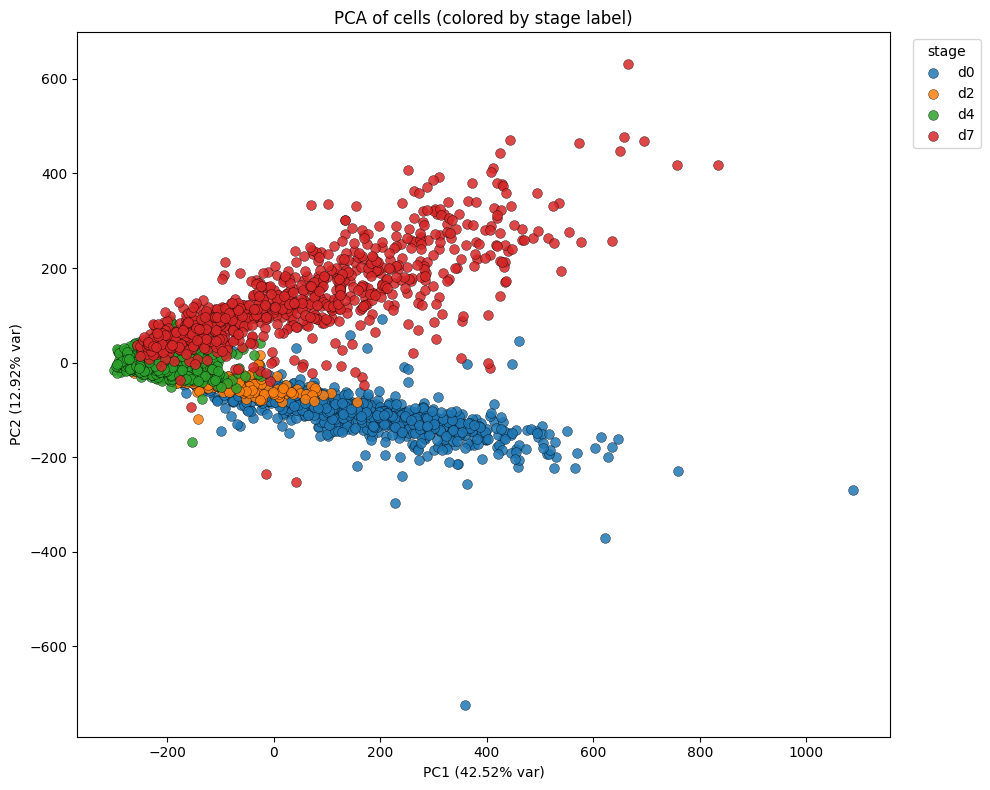

In [66]:
# PCA on cells (samples are columns of X) and scatter plot colored by y
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)  # shape: (n_cells, 2)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.2 Select top 2,000 HVGs:

Normalize and Select Highly-Variable Genes:

In [67]:
print(adata.obs.columns)

Index(['condition'], dtype='object')


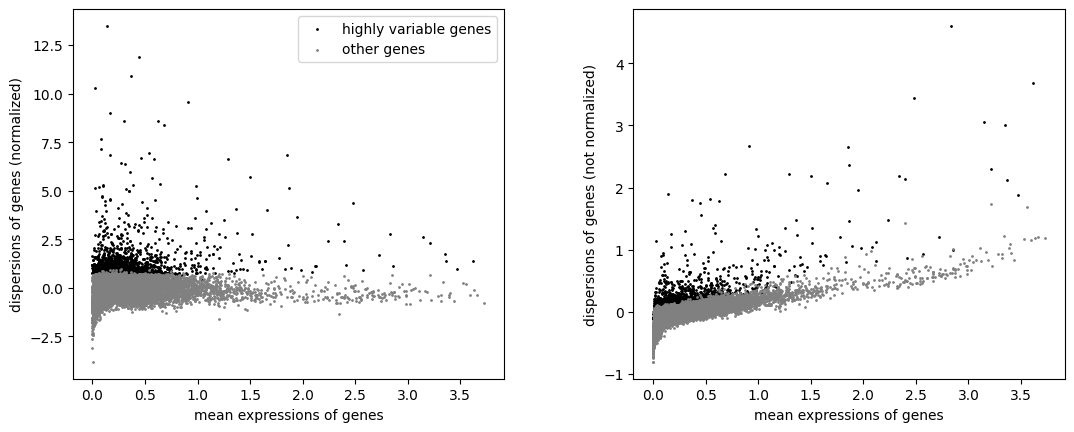

In [68]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="condition", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [69]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [70]:
# Overwrite X and y using the (HVG-subset) adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (2717, 2000)
y.shape: (2717,)


PCA of log1p transformed 2000 HVGs:

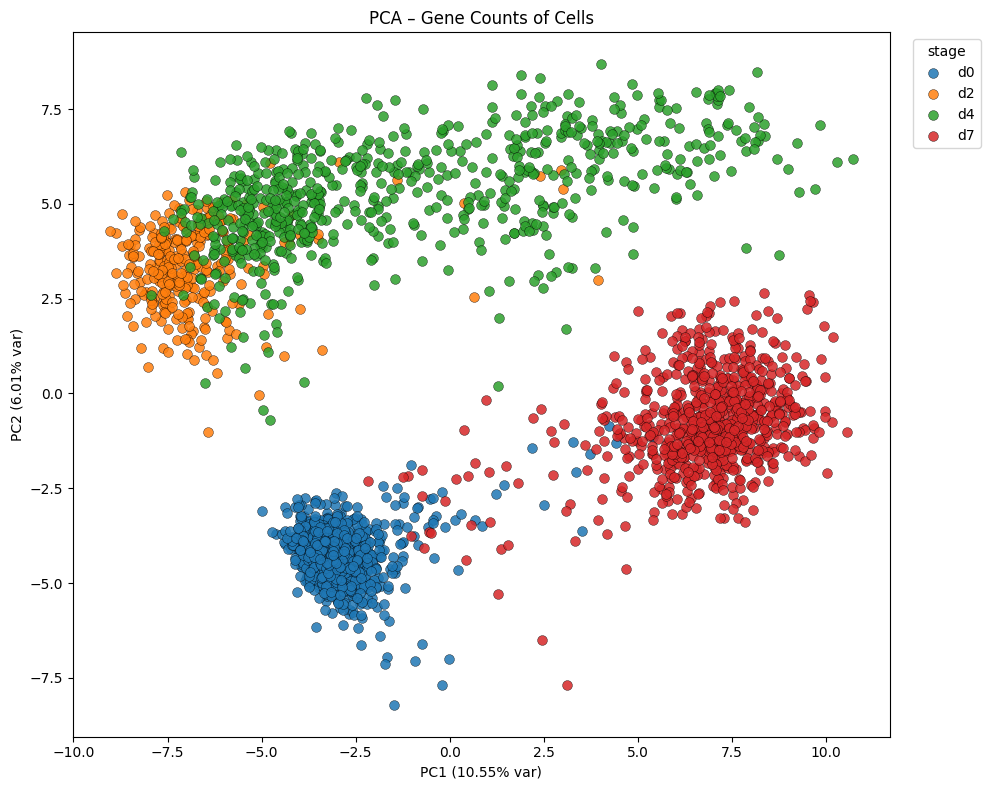

In [71]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

# plt.scatter(pc_df['PC1'], pc_df['PC2'], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA – Gene Counts of Cells")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.3 Perform PCA to 50 PCs (analogous to scMINER):

scMINER selects top 2000 HVGs and then applies PCA to obtain 50 PCs. We will follow this same preprocessing steps.

In [72]:
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X)
print("X_pca_50 shape:", X_pca_50.shape)

X_pca_50 shape: (2717, 50)


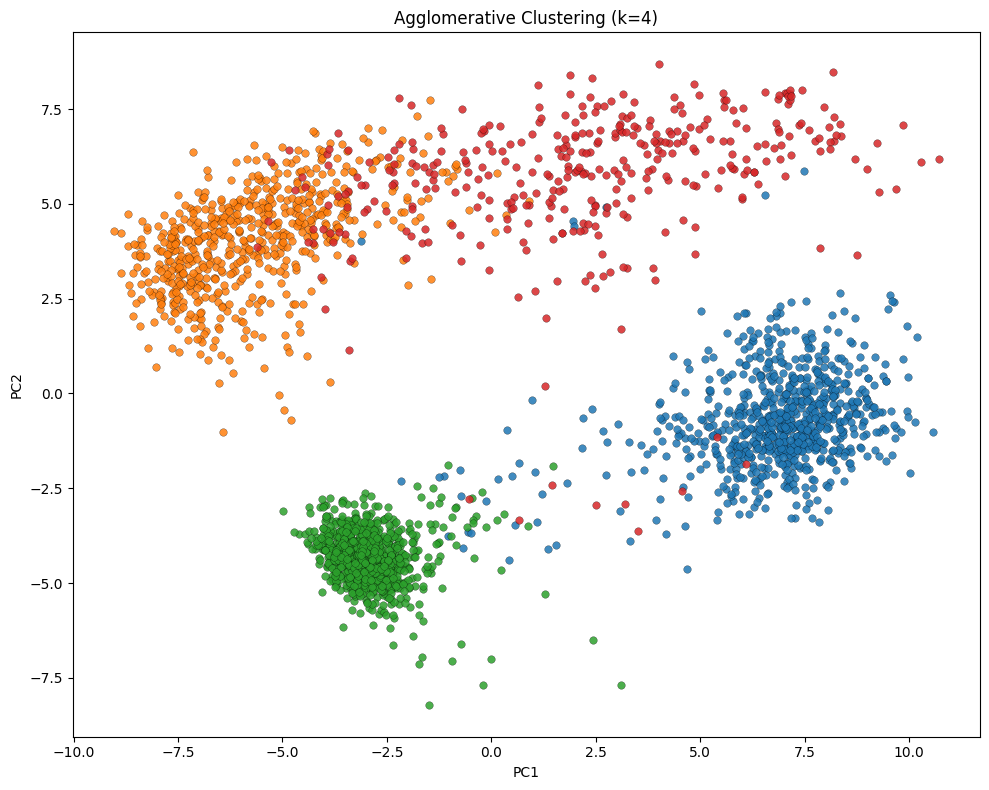

In [73]:
# KMeans clustering with k=3
# estimator = KMeans(n_clusters=4, random_state=RANDOM_SEED)
estimator = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = estimator.fit_predict(X_pca_50)

# Plot PCA results colored by KMeans (k=3) clusters
plt.figure(figsize=(10, 8))
unique_clusters3 = np.unique(labels)
cmap = plt.get_cmap('tab10')
color_map = {cl: cmap(i % 10) for i, cl in enumerate(unique_clusters3)}
for cl in unique_clusters3:
    sel = labels == cl
    plt.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], label=f"Cluster {cl}", color=color_map[cl], s=30, alpha=0.85, edgecolor='k', linewidth=0.2)
plt.title("Agglomerative Clustering (k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.4 Perform Clustering with "Oracle" Number of Clusters:

In [ ]:
y_true = adata.obs['condition'].values
n_clusters = len(pd.Categorical(y_true).categories)

# KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_pca_50)
ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)

# Agglomerative (Ward linkage)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg.fit_predict(X_pca_50)
ari_agg = adjusted_rand_score(y_true, agg_labels)

# Leiden
leiden = LeidenClustering(n_clusters=n_clusters, random_state=RANDOM_SEED)
leiden_labels = leiden.fit_predict(X_pca_50)
ari_leiden = adjusted_rand_score(y_true, leiden_labels)

# Spectral Clustering (median heuristic for gamma)
gamma = gamma_quantile_approx(X_pca_50, q=0.5)
spectral = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=gamma, random_state=RANDOM_SEED)
spectral_labels = spectral.fit_predict(X_pca_50)
ari_spectral = adjusted_rand_score(y_true, spectral_labels)

print(f"ARI KMeans: {ari_kmeans:.4f}")
print(f"ARI Agglomerative (Ward): {ari_agg:.4f}")
print(f"ARI Leiden: {ari_leiden:.4f}")
print(f"ARI Spectral (gamma={gamma:.6f}): {ari_spectral:.4f}")

ARI KMeans: 0.8065
ARI Agglomerative (Ward): 0.8257
ARI Leiden: 0.5409
ARI Spectral (gamma=0.002918): 0.8255


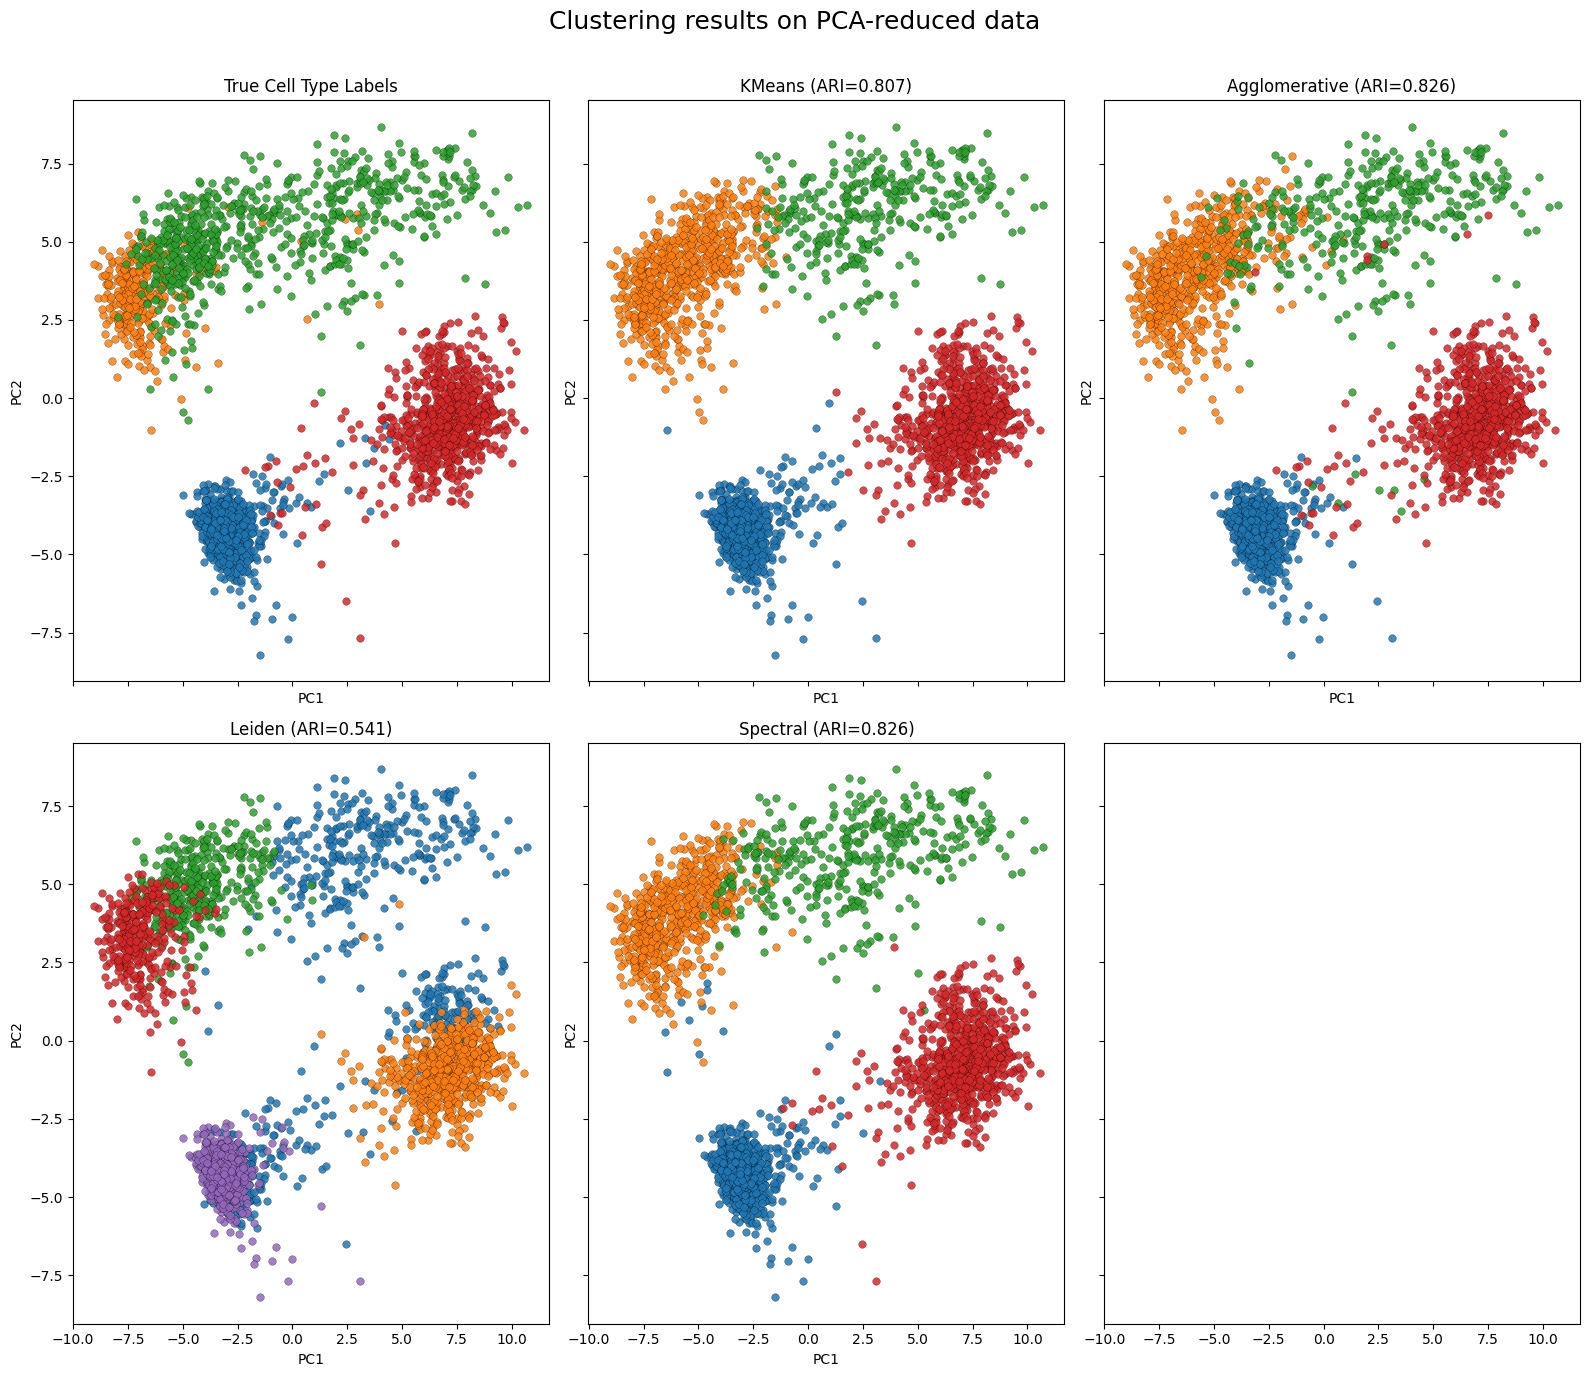

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(16, 14), sharex=True, sharey=True)

# Plot true labels
pc_df['label'] = y
ax_true = axes[0, 0]
for lab in pd.Categorical(y_true).categories:
    sel = pc_df['label'] == lab
    ax_true.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=lab)
ax_true.set_title("True Cell Type Labels")
ax_true.set_xlabel("PC1")
ax_true.set_ylabel("PC2")
# ax_true.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

titles = [
    f"KMeans (ARI={ari_kmeans:.3f})",
    f"Agglomerative (ARI={ari_agg:.3f})",
    f"Leiden (ARI={ari_leiden:.3f})",
    f"Spectral (ARI={ari_spectral:.3f})"
]
clusterings = [kmeans_labels, agg_labels, leiden_labels, spectral_labels]
aligned_clusterings = [align_labels(pd.Categorical(y_true).codes, labels) for labels in clusterings]

for ax, labels, title in zip(axes.flat[1:], aligned_clusterings, titles):
    for cluster in np.unique(labels):
        sel = labels == cluster
        ax.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=f"Cluster {cluster}")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    # ax.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.suptitle("Clustering results on PCA-reduced data", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

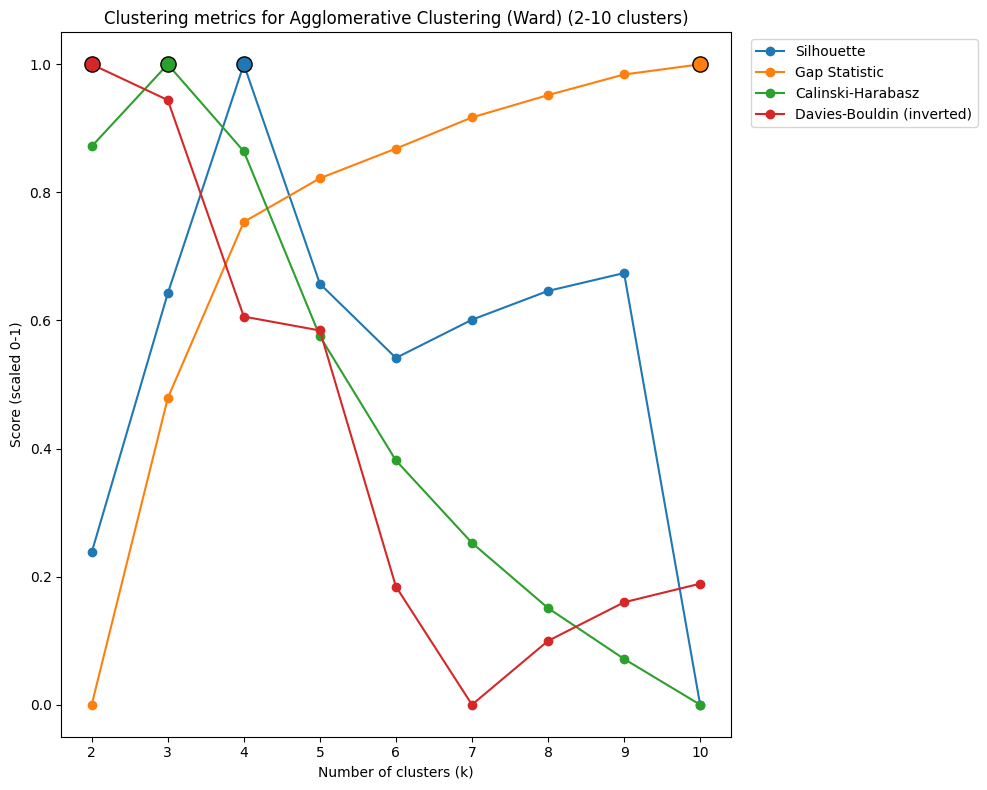

In [79]:
# Prepare storage for metrics
K = 10
ks = np.arange(2, K+1)

# gamma = gamma_quantile_approx(X_pca_50, q=0.5)

silhouette_scores = []
gap_scores = []
calinski_scores = []
davies_scores = []

for k in ks:
    # kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    # labels = kmeans.fit_predict(X_pca_50)
    
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_pca_50)
    
    # spectral = SpectralClustering(n_clusters=k, gamma=gamma, random_state=RANDOM_SEED)
    # labels = spectral.fit_predict(X_pca_50)
    
    # Silhouette
    sil = silhouette_score(X_pca_50, labels)
    silhouette_scores.append(sil)
    
    # Gap Statistic
    gap = gap_statistic(X_pca_50, labels, n_refs=10, algorithm=KMeans, random_state=RANDOM_SEED)
    gap_scores.append(gap)
    
    # Calinski-Harabasz (scaled)
    ch = calinski_harabasz_score(X_pca_50, labels)
    calinski_scores.append(ch)
    
    # Davies-Bouldin (inverted)
    db = davies_bouldin_inv(X_pca_50, labels)
    davies_scores.append(db)

# Scale all scores to [0, 1]
scaler = MinMaxScaler()
silhouette_scores_scaled = scaler.fit_transform(np.array(silhouette_scores).reshape(-1, 1)).flatten()
gap_scores_scaled = scaler.fit_transform(np.array(gap_scores).reshape(-1, 1)).flatten()
calinski_scores_scaled = scaler.fit_transform(np.array(calinski_scores).reshape(-1, 1)).flatten()
davies_scores_scaled = scaler.fit_transform(np.array(davies_scores).reshape(-1, 1)).flatten()

# Find maxima for each metric
max_sil_idx = np.argmax(silhouette_scores_scaled)
max_gap_idx = np.argmax(gap_scores_scaled)
max_ch_idx = np.argmax(calinski_scores_scaled)
max_db_idx = np.argmax(davies_scores_scaled)

plt.figure(figsize=(10, 8))
plt.plot(ks, silhouette_scores_scaled, label='Silhouette', marker='o')
plt.plot(ks, gap_scores_scaled, label='Gap Statistic', marker='o')
plt.plot(ks, calinski_scores_scaled, label='Calinski-Harabasz', marker='o')
plt.plot(ks, davies_scores_scaled, label='Davies-Bouldin (inverted)', marker='o')

# Highlight maxima
plt.scatter(ks[max_sil_idx], silhouette_scores_scaled[max_sil_idx], color='C0', s=120, edgecolor='k', zorder=5, label='Silhouette max')
plt.scatter(ks[max_gap_idx], gap_scores_scaled[max_gap_idx], color='C1', s=120, edgecolor='k', zorder=5, label='Gap Statistic max')
plt.scatter(ks[max_ch_idx], calinski_scores_scaled[max_ch_idx], color='C2', s=120, edgecolor='k', zorder=5, label='Calinski-Harabasz max')
plt.scatter(ks[max_db_idx], davies_scores_scaled[max_db_idx], color='C3', s=120, edgecolor='k', zorder=5, label='Davies-Bouldin max')

handles, labels_ = plt.gca().get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels_) if "max" not in l]

plt.xlabel('Number of clusters (k)')
plt.ylabel('Score (scaled 0-1)')
plt.title('Clustering metrics for Agglomerative Clustering (Ward) (2-10 clusters)')
plt.legend([h for h, _ in filtered], [l for _, l in filtered], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

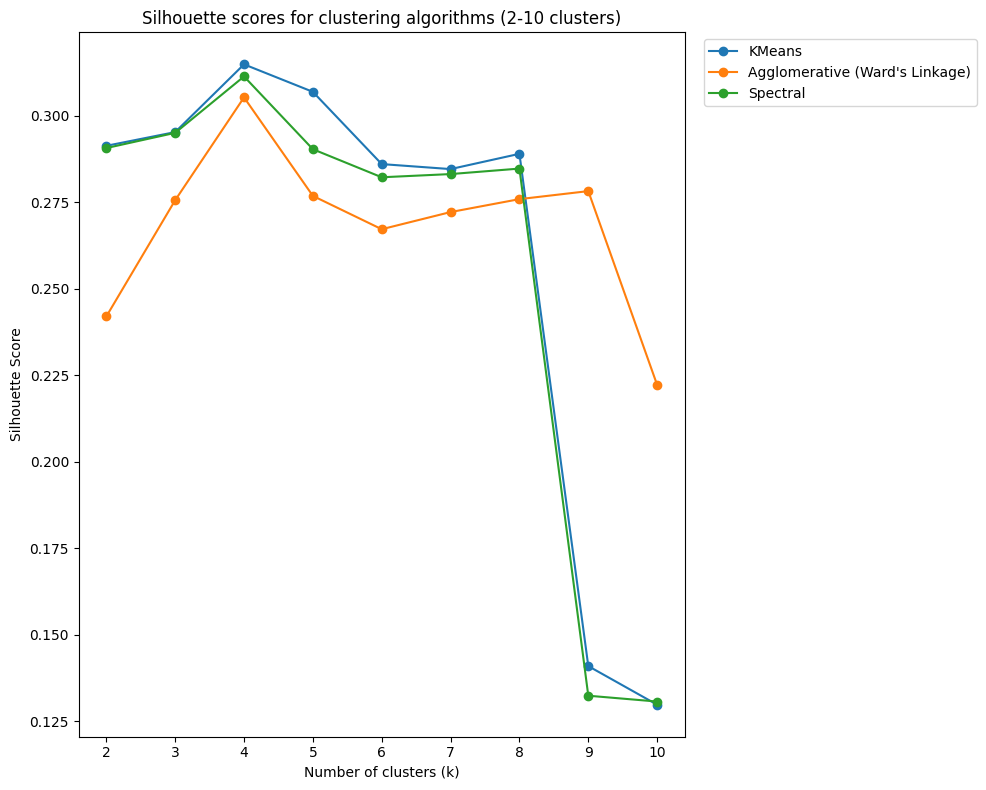

In [80]:
silhouette_scores_kmeans = []
silhouette_scores_agg = []
silhouette_scores_spectral = []

for k in ks:
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    labels_kmeans = kmeans.fit_predict(X_pca_50)
    sil_kmeans = silhouette_score(X_pca_50, labels_kmeans)
    silhouette_scores_kmeans.append(sil_kmeans)
    
    # Agglomerative (Ward's Linkage)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_agg = agg.fit_predict(X_pca_50)
    sil_agg = silhouette_score(X_pca_50, labels_agg)
    silhouette_scores_agg.append(sil_agg)
    
    # Spectral Clustering (median heuristic for gamma)
    spectral = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma, random_state=RANDOM_SEED)
    labels_spectral = spectral.fit_predict(X_pca_50)
    sil_spectral = silhouette_score(X_pca_50, labels_spectral)
    silhouette_scores_spectral.append(sil_spectral)

plt.figure(figsize=(10, 8))
plt.plot(ks, silhouette_scores_kmeans, label='KMeans', marker='o')
plt.plot(ks, silhouette_scores_agg, label='Agglomerative (Ward\'s Linkage)', marker='o')
plt.plot(ks, silhouette_scores_spectral, label='Spectral', marker='o')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette scores for clustering algorithms (2-10 clusters)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---

## 4. Run CARVE:

In [84]:
K = 5
ks = np.arange(2, K+1)

# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_SEED)
# idx = next(sss.split(np.arange(len(y)), y))[1]
# gamma = gamma_quantile_approx(X_pca_50[idx], q=0.50)

model_grids = [
    (KMeans, {"n_clusters": ks}), 
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "complete", "single"]})
    # (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    # (SpectralClustering, {"n_clusters": ks, "gamma": [gamma]}),
]

carve_klein = CARVE(
    model_grids=model_grids,
    B=20,
    n_jobs=N_JOBS, 
    random_state=RANDOM_SEED
)

carve_klein.fit(
    X_pca_50
)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 2717
[CARVE] n_features         : 50
[CARVE] K                  : 10
[CARVE] B (resamples)      : 20
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 16
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/16] est=KMeans n_clusters=2 | ARI_stab=0.698±0.103  ARI_gen=0.642±0.105  ARI_avg=0.670±0.081
[CARVE] [2/16] est=KMeans n_clusters=3 | ARI_stab=0.953±0.023  ARI_gen=0.892±0.038  ARI_avg=0.923±0.027
[CARVE] [3/16] est=KMeans n_clusters=4 | ARI_stab=0.952±0.023  ARI_gen=0.967±0.009  ARI_avg=0.959±0.014
[CARVE] [4/16] est=KMeans n_clusters=5 | ARI_stab=0.858±0.020  ARI_gen=0.864±0.016  ARI_avg=0.861±0.013
[CARVE] [5/16] est=AgglomerativeClustering n_clusters=2 | ARI_stab=0.839±0.026  ARI_gen=0

,K,10
,B,20
,rho,0.6
,model_grids,"[(<class 'sklea...means.KMeans'>, ...), (<class 'sklea...veClustering'>, ...)]"
,norm_options,None
,dr_options,None
,ref_labels,None
,n_jobs,10
,random_state,42
,verbose,1


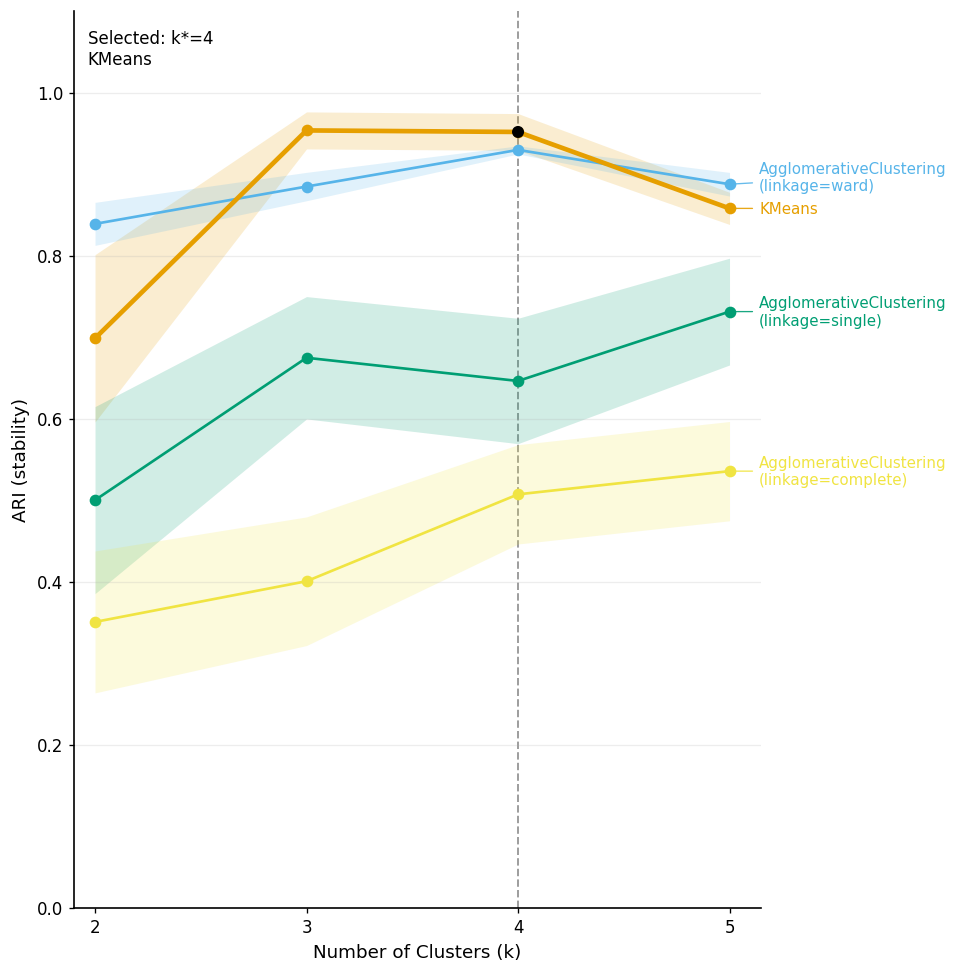

In [85]:
# carve_klein.plot_results(measure='generalizability', rule='1se')
carve_klein.plot_results(interactive=False)

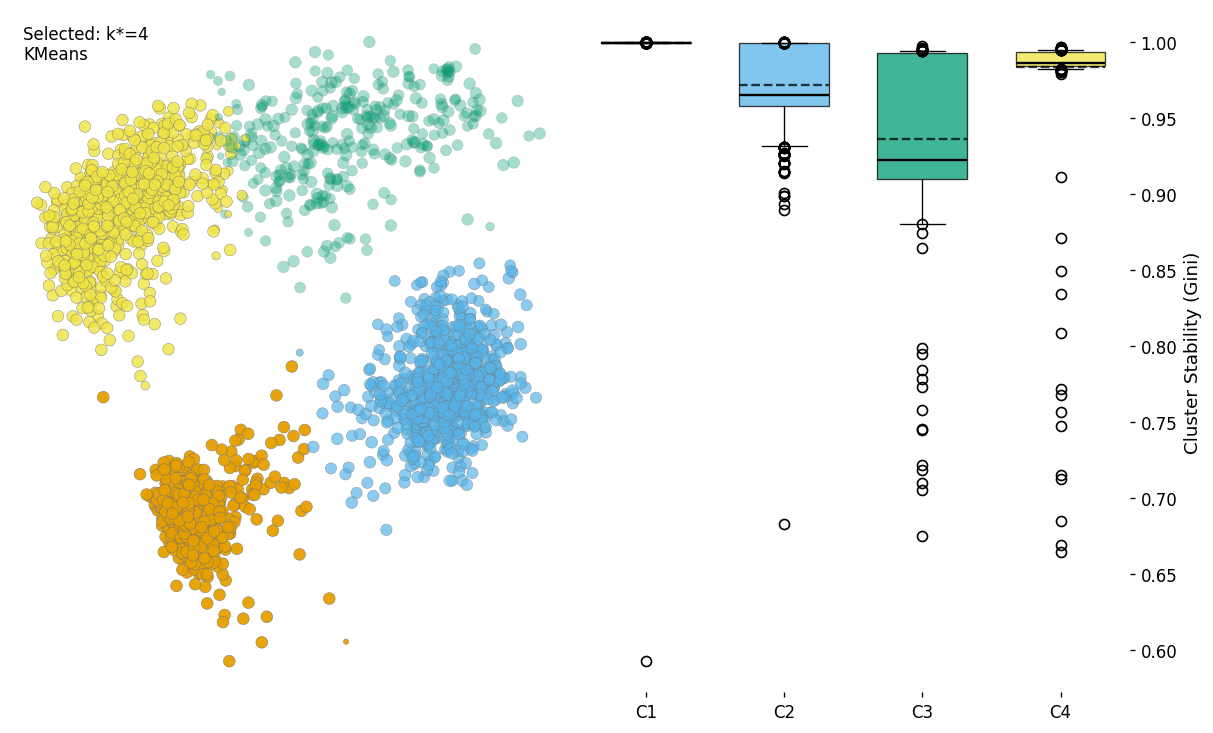

In [86]:
# from umap import UMAP
# carve_klein.plot_clustering(rule='1se', interactive=False, show_scatter_axes=True, dr=UMAP(n_components=2, random_state=RANDOM_SEED))

# from sklearn.manifold import TSNE
# carve_klein.plot_clustering(rule='1se', interactive=False, dr=TSNE(n_components=2, random_state=RANDOM_SEED))

carve_klein.plot_clustering(rule='quantile', interactive=False)

In [24]:
# from sklearn.manifold import TSNE, Isomap
# from sklearn.decomposition import KernelPCA

# carve_klein.plot_consensus_clustering(measure='s', rule='1se', dr=TSNE(n_components=2, init="pca", learning_rate="auto"))
# carve_klein.plot_consensus_clustering(measure='s', rule='1se', dr=Isomap(n_components=2, n_neighbors=15))
# carve_klein.plot_consensus_clustering(measure='s', rule='1se', dr=KernelPCA(n_components=2, kernel="rbf", gamma=0.5))

# carve_klein.plot_consensus_clustering(measure='s', rule='1se')

In [25]:
# carve_klein.plot_consensus_matrix(measure='s', rule='1se')

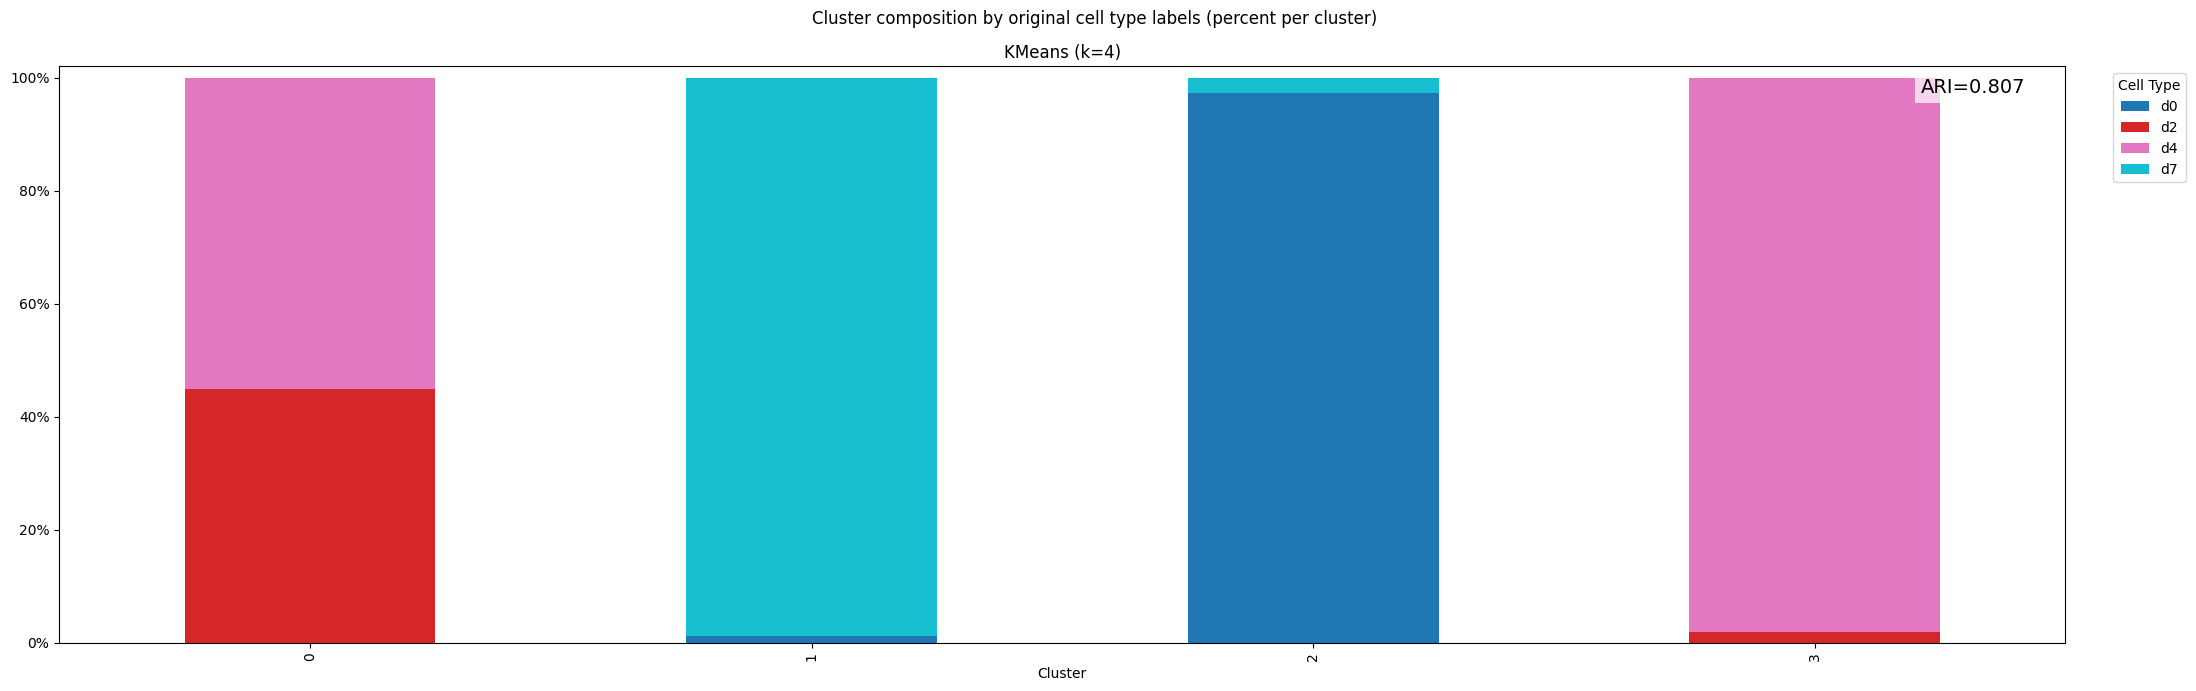

In [28]:
def cluster_composition_percent(labels, y, categories):
    comp = []
    for i in range(len(np.unique(labels))):
        idx = np.where(labels == i)[0]
        counts = Counter(y[idx])
        total = sum(counts.get(cat, 0) for cat in categories)
        comp.append([counts.get(cat, 0) / total if total > 0 else 0 for cat in categories])
    return pd.DataFrame(comp, columns=categories)

fig, axes = plt.subplots(1, 1, figsize=(22, 7), sharey=True)
categories = y.categories

# KMeans k=4
kmeans4 = KMeans(n_clusters=4, random_state=RANDOM_SEED)
labels_kmeans4 = kmeans4.fit_predict(X_pca_50)
df_kmeans4 = cluster_composition_percent(labels_kmeans4, y, categories)
df_kmeans4.plot(kind='bar', stacked=True, ax=axes, colormap='tab10', legend=False)
axes.set_title('KMeans (k=4)')
axes.set_ylim(0, 1.02)
axes.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))

axes.set_xlabel('Cluster')
axes.legend(title='Cell Type', bbox_to_anchor=(1.02, 1), loc='upper left')

# Show ARI scores
ari_kmeans4 = adjusted_rand_score(y, labels_kmeans4)
axes.text(0.98, 0.98, f"ARI={ari_kmeans4:.3f}", ha='right', va='top', transform=axes.transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.suptitle('Cluster composition by original cell type labels (percent per cluster)')
plt.tight_layout()
plt.show()

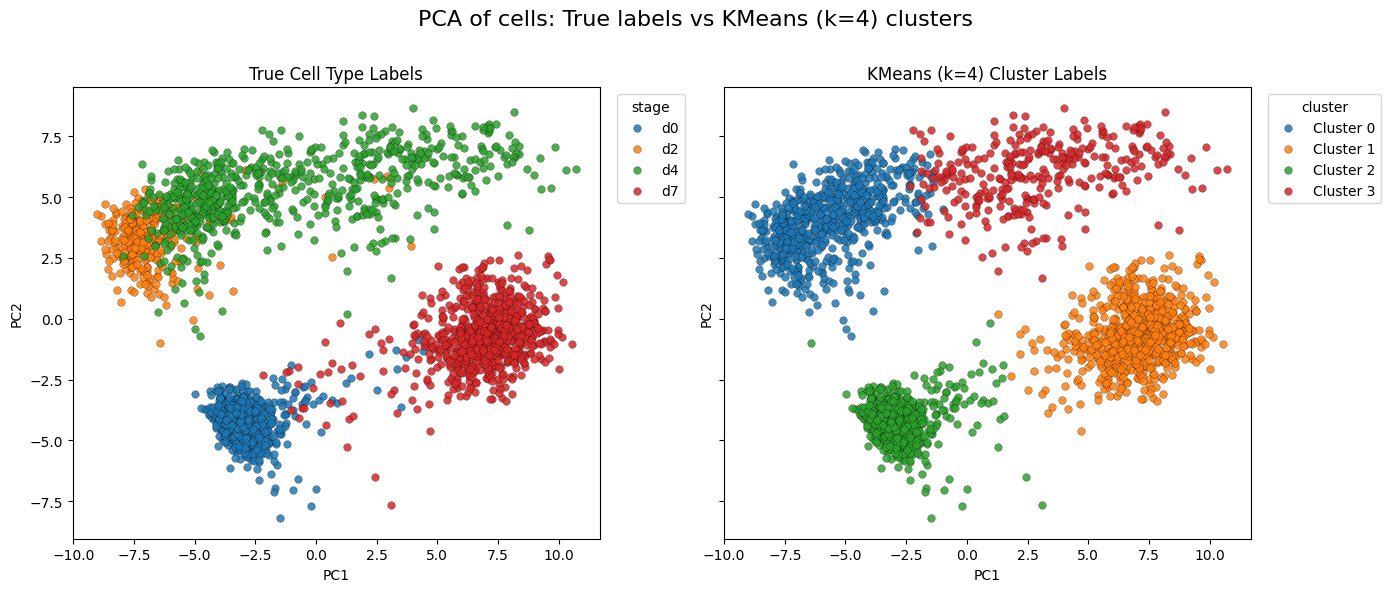

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Left: True labels
labels_true = pd.Categorical(y).categories
cmap = plt.get_cmap('tab10')
color_map_true = {lab: cmap(i % 10) for i, lab in enumerate(labels_true)}
for lab in labels_true:
    sel = pc_df['label'] == lab
    axes[0].scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], label=lab, color=color_map_true[lab], s=30, alpha=0.85, edgecolor='k', linewidth=0.2)
axes[0].set_title("True Cell Type Labels")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')

# Right: KMeans (k=4) labels
unique_clusters = np.unique(labels_kmeans4)
cmap2 = plt.get_cmap('tab10')
color_map_kmeans = {cl: cmap2(i % 10) for i, cl in enumerate(unique_clusters)}
for cl in unique_clusters:
    sel = labels_kmeans4 == cl
    axes[1].scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], label=f"Cluster {cl}", color=color_map_kmeans[cl], s=30, alpha=0.85, edgecolor='k', linewidth=0.2)
axes[1].set_title("KMeans (k=4) Cluster Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle("PCA of cells: True labels vs KMeans (k=4) clusters", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---